# Tech Challenge - Fase 1 | Hospital Universitário: IA para Diagnóstico de Câncer de Mama

**Curso:** Pós-Tech em Machine Learning / IA  
**Projeto:** Sistema Inteligente de Suporte ao Diagnóstico Médico  
**Dataset:** Diagnóstico de Câncer de Mama (`diagnosticoCancerMama.csv`)

**Integrantes:**

**Bianca Maciel - RM376200**

**Eduardo O Charrone - RM377641**

**Guilherme Mendes Alburquerque - RM378723**

**Igor Matos de Andrade - RM377344**

**João Augusto Gonçalves de Aragão - RM377385**

---
### Contexto e Objetivo
Atender ao desafio de implementar um sistema de IA focado em Machine Learning para auxiliar médicos na triagem rápida e precisa de exames de câncer de mama (Maligno vs. Benigno).

****

**Importação das bibliotecas a serem utilizadas no projeto**

In [35]:
#import sys
#from pathlib import Path

#REPO_URL = "https://github.com/iigormatos/tech-challenge-fase1-v1.git"
#EM_COLAB = "google.colab" in sys.modules

#if EM_COLAB:
    #PROJECT_ROOT = Path("/content/tech-challenge-fase1-v1")
    #if not PROJECT_ROOT.exists():
        #!git clone -q {REPO_URL} {PROJECT_ROOT}
    #%cd {PROJECT_ROOT}
    #!pip install -q missingno shap
#else:
    #PROJECT_ROOT = Path.cwd().parent

#sys.path.insert(0, str(PROJECT_ROOT))
#print(CANCER_MAMA_CSV)
#from src.config import RANDOM_STATE, CANCER_MAMA_CSV

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

**Importando dados para iniciar análise**

In [37]:
dados = pd.read_csv("../diagnosticoCancerMama.csv", sep=',')

print(f"Dimensões do dataSet original: {dados.shape[0]} linhas e {dados.shape[1]} colunas")

dados.head()

dados.describe()

Dimensões do dataSet original: 569 linhas e 33 colunas


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [38]:
## 1. Análise Exploratória e Limpeza de dados

In [56]:
#Limpeza de colunas irrelevantes e nulas da base
dadosClean = dados.drop(columns=['id', 'Unnamed: 32'], errors=['ignore']).copy()

#Tratar string: Forçar conversão para numerico, exceto a coluna diagnosis
dadosCleanColunasString = dadosClean.drop(columns=['diagnosis'], axis=1).columns

#Transforma qualquer texto em NaN
dadosClean[dadosCleanColunasString] = dadosClean[dadosCleanColunasString].apply(pd.to_numeric, errors='coerce')

#Preencher possiveis valores de NaN com a mediana da coluna
dadosClean[dadosCleanColunasString] = dadosClean[dadosCleanColunasString].fillna(dadosClean[dadosCleanColunasString].median())

#Mapeamento do target: M-> 1 (Maligno), B -> 0 (Benigno)
label_encoder = LabelEncoder()
colunas=['diagnosis']

for col in colunas:
    dadosClean[col] = label_encoder.fit_transform(dados[col])

#Exibição dos dados após mapeamento e sanitização
print(f"Dimensões do dataSet após limpeza: {dadosClean.shape[0]} linhas e {dadosClean.shape[1]} colunas")
print(f"Quantidade de dados nulos: {dadosClean.isnull().sum().sum()}")

dadosClean.head()

Dimensões do dataSet após limpeza: 569 linhas e 31 colunas
Quantidade de dados nulos: 0


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [57]:
#Verificar as os tipo de dados dentro das colunas importadas
dadosClean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

array([[<Axes: title={'center': 'diagnosis'}>,
        <Axes: title={'center': 'radius_mean'}>,
        <Axes: title={'center': 'texture_mean'}>,
        <Axes: title={'center': 'perimeter_mean'}>,
        <Axes: title={'center': 'area_mean'}>,
        <Axes: title={'center': 'smoothness_mean'}>],
       [<Axes: title={'center': 'compactness_mean'}>,
        <Axes: title={'center': 'concavity_mean'}>,
        <Axes: title={'center': 'concave points_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'fractal_dimension_mean'}>,
        <Axes: title={'center': 'radius_se'}>],
       [<Axes: title={'center': 'texture_se'}>,
        <Axes: title={'center': 'perimeter_se'}>,
        <Axes: title={'center': 'area_se'}>,
        <Axes: title={'center': 'smoothness_se'}>,
        <Axes: title={'center': 'compactness_se'}>,
        <Axes: title={'center': 'concavity_se'}>],
       [<Axes: title={'center': 'concave points_se'}>,
        <Axes: title={'cent

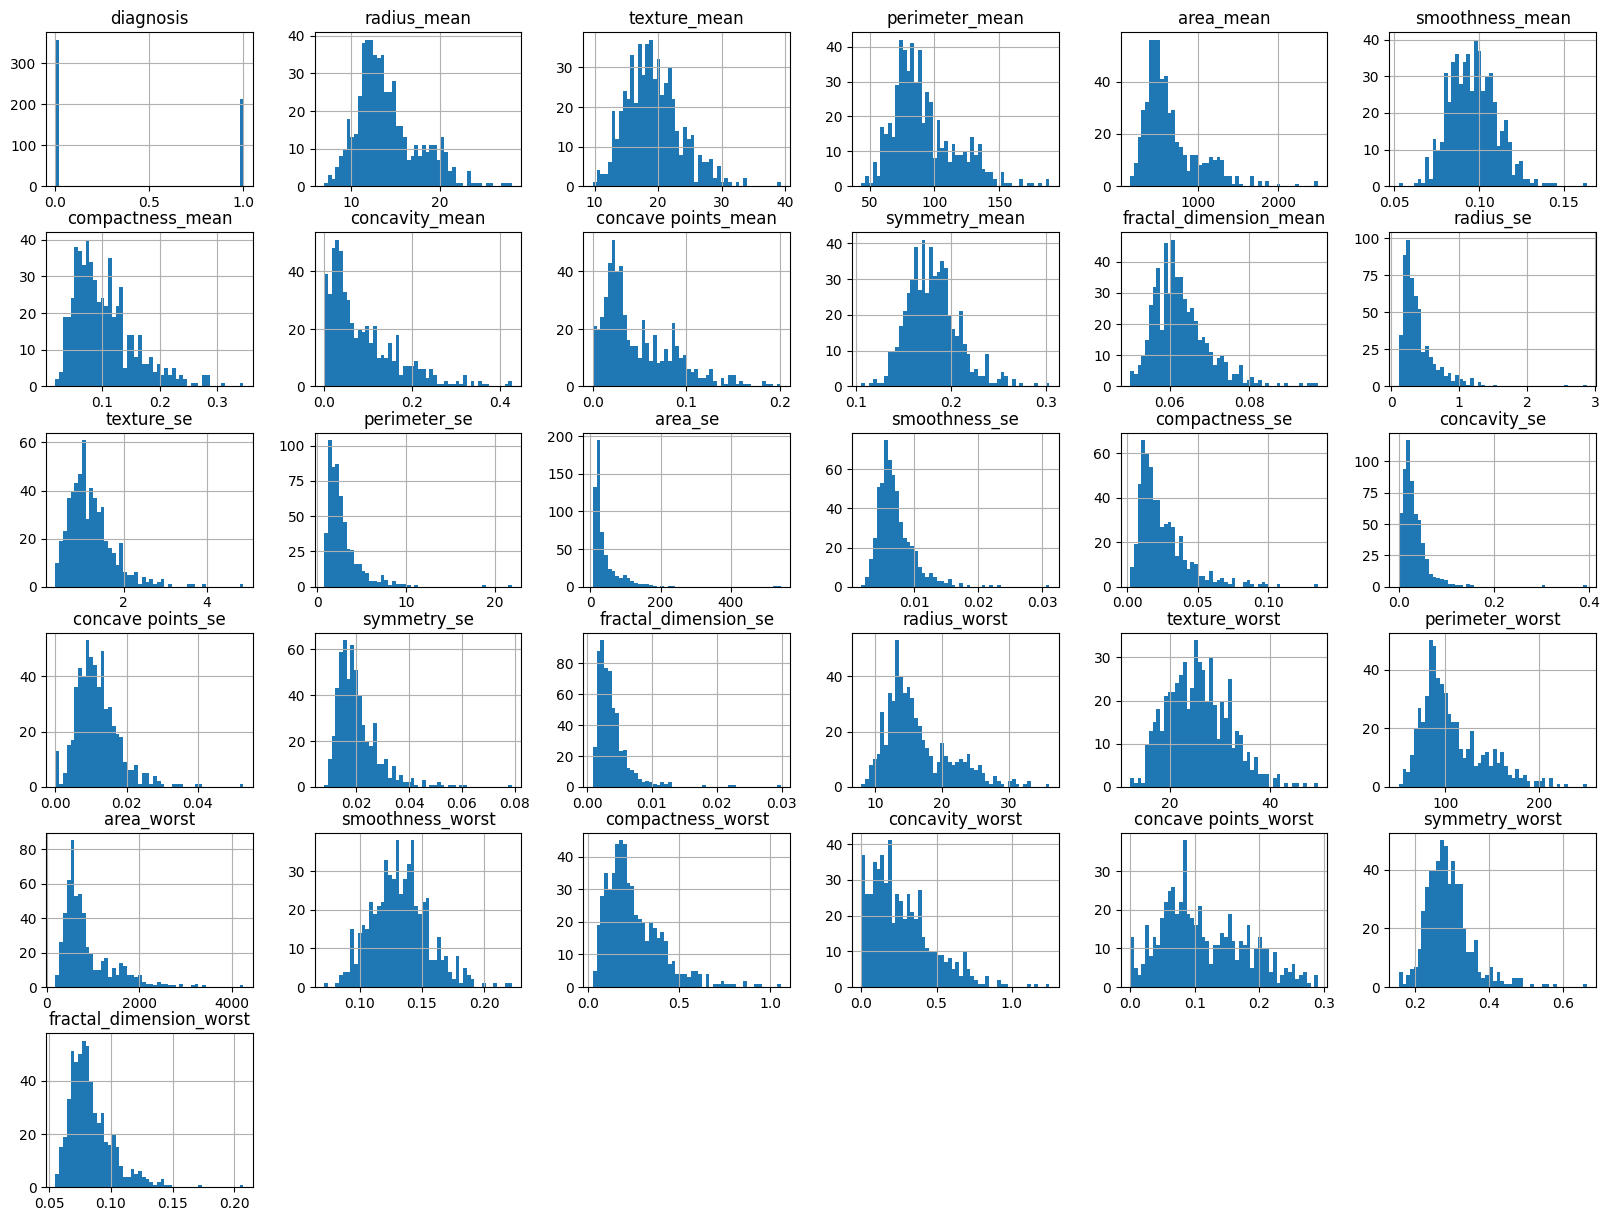

In [58]:
#Análise inicial de histograma com os dados sanitizados

dadosClean.hist(bins=50, figsize=(20,15))

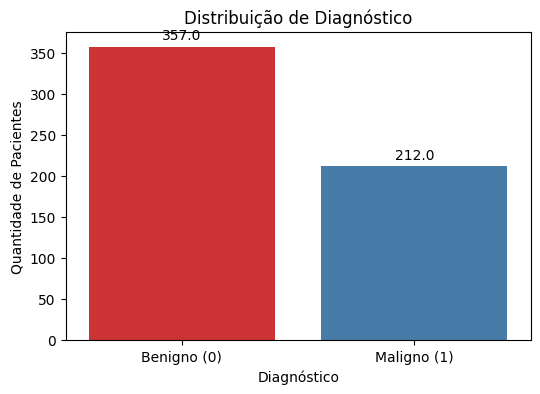

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440


In [59]:
#Distribuição das Classes
plt.figure(figsize=(6, 4))
diagnosticos = sns.countplot(x='diagnosis', data=dadosClean, palette='Set1', hue='diagnosis', legend=False)
plt.xticks([0, 1], ['Benigno (0)', 'Maligno (1)'])
plt.title('Distribuição de Diagnóstico')
plt.xlabel('Diagnóstico')
plt.ylabel('Quantidade de Pacientes')

#Adiciona contagem no topo das barras
for p in diagnosticos.patches:
    diagnosticos.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.show()

#Estatisticas das variaves principais (Média dos Parâmetros)
display(dadosClean.filter(regex='_mean').describe())